## General Imports

In [1]:
from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP

## Basic Syntax

In [2]:
net = Network()                       # instantiate network
net.layer = [NodeGroup(LIF(), 32),    # add a list of node groups
             NodeGroup(LIF(), 10)]  
net.dense = EdgeGroup(net.layer[0],   # add an edge group connecting
                      net.layer[1],   # the node groups
                      PSP())
net.inp = NodePort()                  # add an input port (not linked)
net.out = NodeList(net.layer[1][::2]) # add an output list (slicing)

net.build()       # build network topology
print(net)        # print the topological components

info: flattening network topology
(node) layer[0]
(node) layer[1]
(edge) dense: (node) layer[0] -> (node) layer[1]
(port) inp <- (no link)
(list) out


## Networks

In [3]:
import itertools

class Linear(Network):
    def __init__(self, size=256):
        super().__init__()      # base class initialization (required)
        self.size = size        # user-defined network parameters
        self.inp = NodePort()   # unsized node port (generates dependency)
        self.ctrl = NodePort(1) # sized node port (no dependency)

    def build(self):
        # Layers (using supplied parameters)
        self.layer = NodeGroup(LIF(), self.size)

        # Procedurally generating edges (using resolved port information)
        edges = [(i,j) for i,j in itertools.product(
            range(self.inp.size),range(self.layer.size))]

        # Connections (using node port placeholder)
        self.dense = EdgeGroup(self.inp, self.layer, PSP(), edges=edges)

        return

net = Network()                 # instantiate network
net.inp = NodeGroup(IN(), 12)   # add an input node group
net.ff = [Linear(32),           # add a list of networks
          Linear(10)]
# connect topological components (using dot notation)
net.connect(net.inp, net.ff[0].inp)
net.connect(net.ff[0].layer, net.ff[1].inp)
net.build()       # build network topology
print(net)        # print the topological components

info: adding list of networks ff
info: linking port ff[0].inp
info: waiting on source ff[0].layer
info: resolving dependency for ff[0].inp
info: building network ff[0]
info: linking port ff[1].inp
info: resolving dependency for ff[1].inp
info: building network ff[1]
info: flattening network topology
(node) inp
(port) ff[0].inp <- (node) inp
(port) ff[0].ctrl <- (no link)
(node) ff[0].layer
(edge) ff[0].dense: (port) ff[0].inp <- (node) inp -> (node) ff[0].layer
(port) ff[1].inp <- (node) ff[0].layer
(port) ff[1].ctrl <- (no link)
(node) ff[1].layer
(edge) ff[1].dense: (port) ff[1].inp <- (node) ff[0].layer -> (node) ff[1].layer


## Nodes and Edges

In [4]:
from dataclasses import dataclass
from sango.model import Neuron, Synapse

@dataclass
class LIF(Neuron):
    model: str = 'LIF'       # model name
    voltage: float = 0.0     # individual parameter
    threshold: float = 1.0
    reset: float = 0.0,      # shared parameter (note: this is for illustration, the
    leak: float = 1.0        #                   basic LIF model provided by Sango has
                             #                   'reset' as an individual parameter)

res = NodeGroup(LIF(threshold=0.9),    # model parameter default
                size=3,                # node group size
                voltage=0.6,           # bulk parameter assignment
                leak=[0.5, 0.4, 0.3])  # individual parameter assignment
res.reset = 0.1                        # shared parameter assignment
res[1].voltage = 0.8                   # individual node parameter assignment

print(res.model)        # ['LIF']
print(res.voltage)      # [0.6 0.8 0.6]
print(res.threshold)    # [0.9 0.9 0.9]
print(res.reset)        # [(0.1,)]
print(res.leak)         # [0.5 0.4 0.3]

['LIF']
[0.6 0.8 0.6]
[0.9 0.9 0.9]
[(0.1,)]
[0.5 0.4 0.3]


In [5]:
@dataclass
class PSP(Synapse):
    model: str = 'PSP'
    delay: float = 1.0
    weight: float = 1.0

rr = EdgeGroup(res, res, PSP(delay=2.0),    # model parameter default
               edges=[(0,1), (1,2), (2,0)], # list of directed tuples (source, target)
               weight=[1.0, 2.0, 3.0])      # individual parameter assignment
rr[(1,2)].delay = 3.0       # individual edge parameter assignment (by tuple)
rr[0].weight = 1.5          # individual edge parameter assignment (by index)

print(rr.delay)       # [2.0 3.0 2.0]
print(rr.weight)      # [1.5 2.0 3.0]

# Edge groups have a mapping from directed tuples to linear indexes
print(rr.edge_map)     # {(0, 1): 0, (1, 2): 1, (2, 0): 2}
print(rr.target_index) # [1, 2, 0]

[2. 3. 2.]
[1.5 2.  3. ]
{(0, 1): 0, (1, 2): 1, (2, 0): 2}
[1, 2, 0]


## Simulation

In [6]:
class Input(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # number of nodes x lists of times

    def build(self):
        # Spike generator
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        
        return

# Define spiking inputs as a list of lists
input_vec = [[2, 4, 5],    # 0,1,1,0,1,0,0   (represented as bit strings,
             [0, 1, 4, 6]] # 1,0,1,0,0,1,1    least significant bit first)

net = Network()                         # instantiate network
net.inp = Input(spike_times=input_vec)  # add an input network

# For illustration, we add some other topological components to the network
from sango.model import LIF # reimport the basic LIF model (which was redefined)
net.ff = Linear(3)
net.connect(net.inp.spikegen, net.ff.inp)
net.build()

info: adding network inp
info: adding network ff
info: building network inp
info: linking port ff.inp
info: resolving dependency for ff.inp
info: building network ff
info: flattening network topology


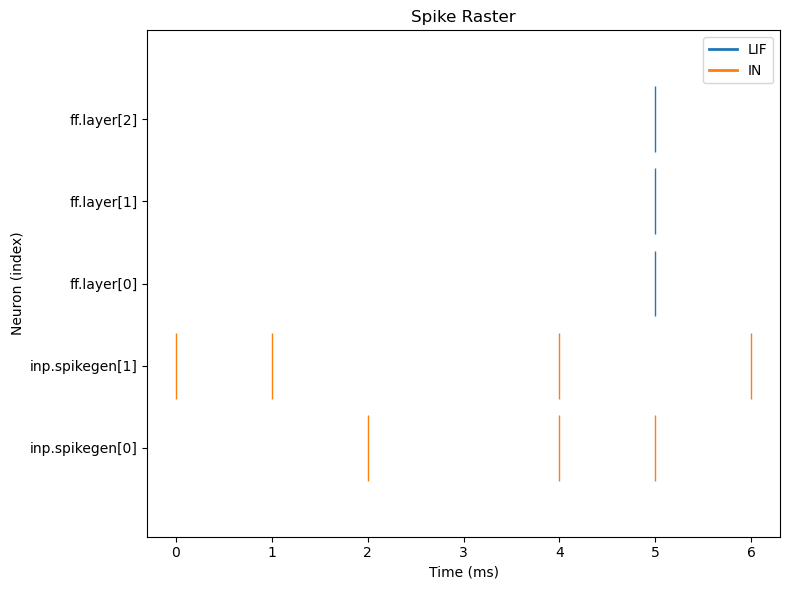

In [7]:
# Import the desired simulator backend
from sango.backend import SimBrian

sim = SimBrian(net)  # Pass the built network to the backend translation layer
sim.compile()        # Convert the network onto the backend execution model
sim.run(10.0)        # Simulate the network (arguments may be backend-specific)

spike_list = sim.get_spikes()                # Get the spike list for each node
node_index = sim.node_map['inp.spikegen[1]'] # Find the index of a node by name
inp1_spike = spike_list[node_index]          # Extract the node spike times

# Plot the spike raster (this uses matplotlib's eventplot)
sim.plot_spikes(tick_names=True)